# Remote Inference with NeMo Retriever

End-to-end document ingestion and retrieval-augmented generation (RAG) using **NVIDIA NIM APIs** — no local GPU required.

**Workflow:**
1. Configure environment and initialise Ray
2. Ingest a PDF via NVIDIA extraction and embedding NIMs → LanceDB
3. Run a simple single-shot RAG query
4. Explore the vector database contents
5. Run a ReAct agent that iteratively queries the knowledge base

## 1. Configuration

Set the environment variables before importing other modules. Replace `NVIDIA_API_KEY` with your key from [build.nvidia.com](https://build.nvidia.com).

In [48]:
import os

# Scratch directory for Ray temporary files — adjust to a local path with sufficient space
os.environ["RAY_TMPDIR"] = "/raid/mwason/tmp"

from dotenv import load_dotenv
load_dotenv()  # reads .env in the working directory

# # NVIDIA NIM API key — obtain from https://build.nvidia.com
# os.environ["NVIDIA_API_KEY"] = "your-api-key-here"

# ── Shared model config ──────────────────────────────────────────────
MODEL_NAME   = "nvidia/nemotron-3-nano-30b-a3b"
API_BASE_URL = "https://integrate.api.nvidia.com/v1"

# ── Shared queries — run through both one-shot RAG and ReAct agent ───
QUERIES = [
    "Which techniques in the paper simultaneously address computational efficiency, training speed, and overfitting, and how do their effects differ?",
    "What constraints imposed by hardware influenced the architecture design, and how did the authors work around them?",
    # "Reconstruct the full training and inference pipeline, highlighting where the procedures diverge and why.",
    # "Compare the relative impact of normalization, overlapping pooling, and multi-GPU training on error reduction, and explain why their gains differ.",
    # "Why does removing even a small convolutional layer degrade performance significantly despite it containing a small fraction of parameters?",
    # "How do dropout and data augmentation complement each other in reducing overfitting, and what limitations remain?",
    # "How does the specialization of GPUs observed in the learned filters relate to the connectivity constraints in the architecture?",
    
    # Add more queries here
]


## 2. Initialise Ray

NeMo Retriever uses Ray for distributed batch processing. The dashboard is disabled here for a lighter footprint.

In [2]:
import ray

ray.init(include_dashboard=False)

2026-03-30 21:47:22,602	INFO worker.py:2013 -- Started a local Ray instance.
/raid/mwason/retriever/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.13
Ray version:,2.54.1


## 3. Ingest Documents

Build the NeMo Retriever ingestion pipeline. Each stage calls a remote NVIDIA NIM:

| Stage | NIM | Purpose |
|-------|-----|---------|
| Extract | `nemotron-page-elements-v3`, `nemotron-graphic-elements-v1`, `nemoretriever-ocr-v1`, `nemotron-table-structure-v1` | Parse layout, graphics, OCR, tables |
| Embed  | `nvidia/llama-nemotron-embed-1b-v2` | Produce text embeddings |
| Upload | — | Write chunks + vectors to LanceDB |

In [18]:
from pathlib import Path
from nemo_retriever import create_ingestor

# Update this path to point at the PDF you want to ingest
PDF_PATH = str(Path("/home/nfs/mwason/NIPS-2012-imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf"))

ingestor = (
    create_ingestor(run_mode="batch")
    .files([PDF_PATH])
    .extract(
        page_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-page-elements-v3",
        graphic_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-graphic-elements-v1",
        ocr_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-ocr-v1",
        table_structure_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-table-structure-v1",
    )
    .embed(
        embed_invoke_url="https://integrate.api.nvidia.com/v1/embeddings",
        model_name="nvidia/llama-nemotron-embed-1b-v2",
        embed_modality="text",
    )
    .vdb_upload()
)

2026-03-30 22:16:39,764	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.


### Run Ingestion

Execute the pipeline. This may take a few minutes on the first run.

In [19]:
ray_dataset = ingestor.ingest()
chunks = ray_dataset.get_dataset().take_all()

print(f"Total chunks: {len(chunks)}")
print(f"Chunk fields: {list(chunks[0].keys())}")

2026-03-30 22:16:42,207	INFO logging.py:392 -- Registered dataset logger for dataset dataset_25_0
2026-03-30 22:16:42,214	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_25_0. Full logs are in /raid/mwason/tmp/ray/session_2026-03-30_21-46-51_501029_2381750/logs/ray-data
2026-03-30 22:16:42,215	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_25_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadBinary] -> ActorPoolMapOperator[MapBatches(DocToPdfConversionActor)] -> TaskPoolMapOperator[MapBatches(PDFSplitActor)] -> TaskPoolMapOperator[MapBatches(PDFExtractionActor)] -> TaskPoolMapOperator[StreamingRepartition[num_rows_per_block=32]] -> ActorPoolMapOperator[MapBatches(PageElementDetectionActor)] -> ActorPoolMapOperator[MapBatches(GraphicElementsActor)] -> ActorPoolMapOperator[MapBatches(TableStructureActor)] -> ActorPoolMapOperator[MapBatches(OCRActor)] -> TaskPoolMapOperator[StreamingRepartition[num_rows_per_block=256]] -> ActorPoolMapOperato

Total chunks: 14
Chunk fields: ['path', 'page_number', 'source_id', 'text', 'page_image', 'images', 'tables', 'charts', 'infographics', 'metadata', 'page_elements_v3', 'page_elements_v3_num_detections', 'page_elements_v3_counts_by_label', 'chart', 'graphic_elements_ocr_v1', 'table', 'table_structure_ocr_v1', 'infographic', 'ocr_v1', '_content_type', 'text_embeddings_1b_v2', '_contains_embeddings', 'text_embeddings_1b_v2_dim', 'text_embeddings_1b_v2_has_embedding']


### Inspect Chunk Content

Print the raw text extracted from every chunk.

In [20]:
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i} ---")
    print(chunk["text"])
    print()

--- Chunk 0 ---
ImageNet Classification with Deep Convolutional
Neural Networks
Alex Krizhevsky
University of Toronto
kriz@cs.utoronto.ca
Ilya Sutskever
University of Toronto
ilya@cs.utoronto.ca
Geoffrey E. Hinton
University of Toronto
hinton@cs.utoronto.ca
Abstract
We trained a large, deep convolutional neural network to classify the 1.2 million
high-resolution images in the ImageNet LSVRC-2010 contest into the 1000 different classes. On the test data, we achieved top-1 and top-5 error rates of 37.5%
and 17.0% which is considerably better than the previous state-of-the-art. The
neural network, which has 60 million parameters and 650,000 neurons, consists
of five convolutional layers, some of which are followed by max-pooling layers,
and three fully-connected layers with a final 1000-way softmax. To make training faster, we used non-saturating neurons and a very efficient GPU implementation of the convolution operation. To reduce overfitting in the fully-connected
layers we employed

## 4. Retriever & LLM Setup

Initialise the `Retriever` against the LanceDB backend and the shared OpenAI-compatible
client. Both the one-shot RAG helper and the ReAct agent defined later use these objects.


In [21]:
from nemo_retriever.retriever import Retriever
from openai import OpenAI

retriever = Retriever(
    lancedb_uri="lancedb",
    lancedb_table="nv-ingest",
    embedder="nvidia/llama-3.2-nv-embedqa-1b-v2",
    top_k=5,
    reranker=False,
)

client = OpenAI(
    base_url=API_BASE_URL,
    api_key=os.environ.get("NVIDIA_API_KEY"),
)


## 5. LanceDB Exploration

Directly inspect the LanceDB vector store — useful for debugging ingestion results, reviewing the schema, and visualising the embedding space.

### Schema & Data

In [22]:
import lancedb

db = lancedb.connect("lancedb")
table = db.open_table("nv-ingest")

print(table.schema)

vector: fixed_size_list<item: float>[2048]
  child 0, item: float
pdf_page: string
filename: string
pdf_basename: string
page_number: int32
source: string
source_id: string
path: string
text: string
metadata: string


In [23]:
df = table.to_pandas()
print(f"Columns: {list(df.columns)}\n")
print(df.head())

Columns: ['vector', 'pdf_page', 'filename', 'pdf_basename', 'page_number', 'source', 'source_id', 'path', 'text', 'metadata']

                                              vector  \
0  [-0.018432617, 0.008575439, 0.0016727448, 0.01...   
1  [0.0024662018, 0.012672424, 5.1498413e-05, 0.0...   
2  [-0.016464233, 0.015396118, -0.0016775131, 0.0...   
3  [-0.0033664703, 0.020980835, 0.003768921, -0.0...   
4  [-0.009170532, 0.020828247, -0.0052452087, 0.0...   

                                            pdf_page  \
0  NIPS-2012-imagenet-classification-with-deep-co...   
1  NIPS-2012-imagenet-classification-with-deep-co...   
2  NIPS-2012-imagenet-classification-with-deep-co...   
3  NIPS-2012-imagenet-classification-with-deep-co...   
4  NIPS-2012-imagenet-classification-with-deep-co...   

                                            filename  \
0  NIPS-2012-imagenet-classification-with-deep-co...   
1  NIPS-2012-imagenet-classification-with-deep-co...   
2  NIPS-2012-imagenet-classific

In [24]:
for i, row in df.iterrows():
    print(f"--- Chunk {i} ---")
    print(f"Text:       {row['text'][:100]}")
    print(f"Page:       {row['page_number']}")
    print(f"Source:     {row['source']}")
    print(f"Vector dim: {len(row['vector'])}")
    print()

--- Chunk 0 ---
Text:       ImageNet Classification with Deep Convolutional
Neural Networks
Alex Krizhevsky
University of Tor
Page:       1
Source:     {"source_id": "/home/nfs/mwason/NIPS-2012-imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf"}
Vector dim: 2048

--- Chunk 1 ---
Text:       Despite the attractive qualities of CNNs, and despite the relative efficiency of their local archite
Page:       2
Source:     {"source_id": "/home/nfs/mwason/NIPS-2012-imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf"}
Vector dim: 2048

--- Chunk 2 ---
Text:       3.1 ReLU Nonlinearity
Figure 1: A four-layer convolutional neural
network with ReLUs (solid line) 
Page:       3
Source:     {"source_id": "/home/nfs/mwason/NIPS-2012-imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf"}
Vector dim: 2048

--- Chunk 3 ---
Text:       0.75 Training error rate 0.25- 20 25 30 35 15 40 Epochs Figure 1: A four-layer convolutional neural 
Pag

### Embedding Visualisation (PCA)

Reduce the high-dimensional embedding vectors to 2D with PCA to get an intuitive sense of how chunks cluster in the embedding space.

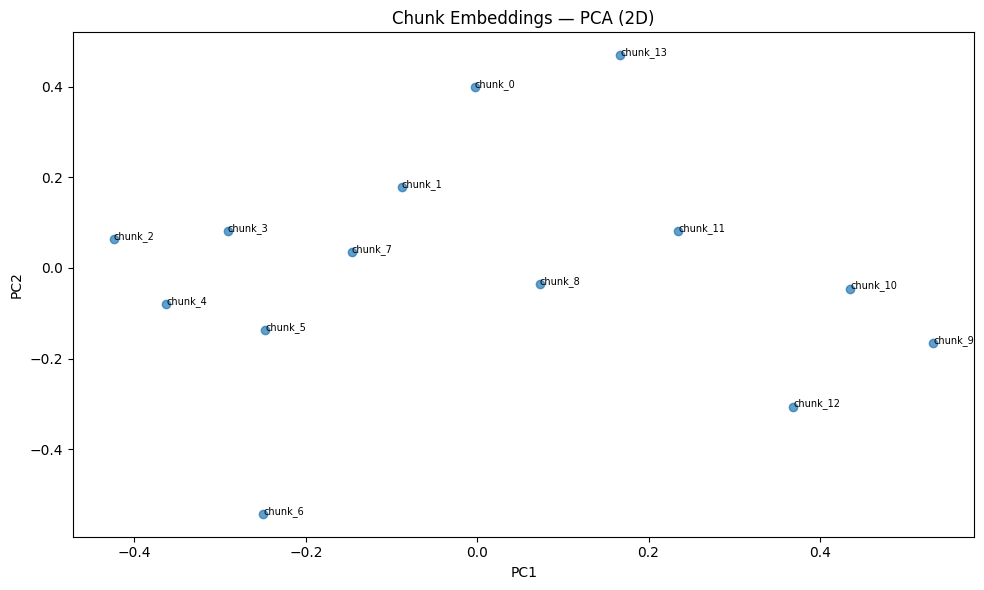

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

vectors = np.stack(df["vector"].values)
reduced = PCA(n_components=2).fit_transform(vectors)

plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)
for i in range(len(df)):
    plt.annotate(f"chunk_{i}", reduced[i], fontsize=7)
plt.title("Chunk Embeddings — PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 6. ReAct Agent Loop

A minimal [ReAct](https://arxiv.org/abs/2210.03629) (Reason + Act) agent that iteratively searches the knowledge base before producing a final answer.

| Tool | Description |
|------|-------------|
| `query_docs` | Semantic search over the ingested vector DB |
| `ingest_pdf` | Ingest a new PDF into the knowledge base at runtime |
| `final_answer` | Return the final answer and terminate the loop |

In [26]:
import json

MAX_ITERATIONS = 8


In [35]:
SYSTEM_PROMPT = """You are a research assistant with access to a document knowledge base.

To answer the user's question:
1. Break the question into sub-questions if needed
2. Search for each sub-question separately using query_docs
3. Use different query phrasings if initial results are insufficient
4. Never repeat the same query twice
5. When you have enough evidence, call final_answer with a complete, grounded response
6. Do not make up information not found in the retrieved documents"""


### Tool Definitions

OpenAI-compatible JSON schemas for the three agent tools, followed by their Python implementations.

In [36]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "query_docs",
            "description": "Search the document knowledge base for relevant text chunks. Call multiple times with different queries to gather more context.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query_string": {
                        "type": "string",
                        "description": "Search query to run against the vector database.",
                    }
                },
                "required": ["query_string"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "ingest_pdf",
            "description": "Ingest a PDF file into the knowledge base. Use only when the user provides a new PDF path.",
            "parameters": {
                "type": "object",
                "properties": {
                    "pdf_path": {
                        "type": "string",
                        "description": "Filesystem path to the PDF.",
                    }
                },
                "required": ["pdf_path"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "final_answer",
            "description": "Provide the final answer when confident. Terminates the loop.",
            "parameters": {
                "type": "object",
                "properties": {
                    "answer": {
                        "type": "string",
                        "description": "The complete answer to return.",
                    }
                },
                "required": ["answer"],
            },
        },
    },
]

In [37]:
def run_query_docs(query_string: str) -> list[dict]:
    hits = retriever.query(query_string)
    # Drop vector field to avoid context bloat (~40 KB per query)
    return [
        {"text": h.get("text", ""), "source": h.get("pdf_basename", ""), "page": h.get("page_number", "")}
        for h in hits
    ]


def run_ingest_pdf(pdf_path: str) -> str:
    pipeline = (
        create_ingestor(run_mode="batch")
        .files([pdf_path])
        .extract(
            page_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-page-elements-v3",
            graphic_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-graphic-elements-v1",
            ocr_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-ocr-v1",
            table_structure_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-table-structure-v1",
        )
        .embed(
            embed_invoke_url="https://integrate.api.nvidia.com/v1/embeddings",
            model_name="nvidia/llama-nemotron-embed-1b-v2",
            embed_modality="text",
        )
        .vdb_upload()
    )
    pipeline.ingest()
    return f"Ingested {pdf_path} successfully."

### ReAct Loop

The `react_agent` function runs the main loop, dispatching tool calls until `final_answer` is invoked or `MAX_ITERATIONS` is reached.

In [38]:
def react_agent(question: str, verbose: bool = True) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    for iteration in range(1, MAX_ITERATIONS + 1):
        if verbose:
            print(f"\n[Iteration {iteration}]")

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            tools=TOOLS,
            tool_choice="auto",
            parallel_tool_calls=False,
        )

        msg = response.choices[0].message
        finish_reason = response.choices[0].finish_reason

        if verbose:
            print(f"  finish_reason: {finish_reason}")

        messages.append(msg)

        # No tool calls — model answered directly
        if finish_reason == "stop" or not msg.tool_calls:
            return msg.content or "(No answer produced)"

        # Process tool calls
        for tool_call in msg.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)

            if verbose:
                print(f"  -> {fn_name}({json.dumps(fn_args)})")

            if fn_name == "final_answer":
                answer = fn_args["answer"]
                if verbose:
                    print(f"\n[Final Answer]\n{answer}")
                return answer
            elif fn_name == "query_docs":
                result = json.dumps(run_query_docs(fn_args["query_string"]), ensure_ascii=False)
            elif fn_name == "ingest_pdf":
                result = run_ingest_pdf(fn_args["pdf_path"])
            else:
                result = f"Unknown tool: {fn_name}"

            if verbose:
                print(f"     result: {result[:200]}...")

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })

    return f"[Agent stopped after {MAX_ITERATIONS} iterations without a final answer]"


## 7. Run Both Methods

Define a `one_shot_rag` helper that mirrors the interface of `react_agent`, then loop over
`QUERIES` and run every query through both methods for a side-by-side comparison.


In [51]:
def one_shot_rag(question: str) -> str:
    hits = retriever.query(question)
    hit_texts = [hit["text"] for hit in hits]
    prompt = (
        f"Given the following retrieved documents, answer the question: {question}\n\n"
        f"Documents:\n{hit_texts}\n"
    )
    completion = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        stream=False,
    )
    return completion.choices[0].message.content


## 8. Multi-Agentic RAG

A four-agent pipeline with a conditional loop-back:

| # | Agent | Role |
|---|-------|------|
| 1 | **Decomposer** | Breaks the query into 2–5 focused sub-queries for retrieval |
| 2 | **Retriever** | Runs each sub-query through the vector DB; deduplicates globally |
| 3 | **Judge** | Filters retrieved chunks to those directly relevant to the question |
| 4 | **Synthesizer** | Produces the final answer — or requests more context (loops back to Agent 2) |

Agent 4 may loop back to Agent 2 up to `MAX_RETRIEVAL_ROUNDS` times before being forced to answer.


In [52]:
# ── Multi-agentic RAG — tunable constants ────────────────────────────────
MAX_RETRIEVAL_ROUNDS = 3   # max times Agent 4 may request more context


In [53]:
# ── Tool schemas for the multi-agentic pipeline ─────────────────────────

DECOMPOSE_TOOL = {
    "type": "function",
    "function": {
        "name": "decompose",
        "description": (
            "Break the original question into 2-5 focused sub-queries, "
            "each independently retrievable from a vector database. "
            "Sub-queries should vary in phrasing and angle to maximise "
            "recall across different document sections."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "sub_queries": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "List of focused sub-queries for retrieval.",
                }
            },
            "required": ["sub_queries"],
        },
    },
}

JUDGE_RELEVANCE_TOOL = {
    "type": "function",
    "function": {
        "name": "judge_relevance",
        "description": (
            "Return the indices of candidate chunks (0-indexed) that are "
            "relevant or potentially useful for answering the question. "
            "Include all chunks with related context; only exclude clearly "
            "off-topic chunks. Include a brief reasoning string."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "relevant_indices": {
                    "type": "array",
                    "items": {"type": "integer"},
                    "description": "Zero-based indices of relevant chunks.",
                },
                "reasoning": {
                    "type": "string",
                    "description": "One-sentence justification for the selection.",
                },
            },
            "required": ["relevant_indices", "reasoning"],
        },
    },
}

REQUEST_MORE_CONTEXT_TOOL = {
    "type": "function",
    "function": {
        "name": "request_more_context",
        "description": (
            "Signal that the current evidence is insufficient. Provide "
            "1-3 NEW sub-queries to retrieve additional context. "
            "Do NOT repeat queries that have already been issued."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "sub_queries": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "New sub-queries not previously issued.",
                }
            },
            "required": ["sub_queries"],
        },
    },
}

FINAL_ANSWER_TOOL = {
    "type": "function",
    "function": {
        "name": "final_answer",
        "description": (
            "Provide the complete, final answer to the original question "
            "based on all accumulated evidence. Terminates the pipeline."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "answer": {
                    "type": "string",
                    "description": "The full, grounded answer to the original question.",
                }
            },
            "required": ["answer"],
        },
    },
}

MA_SYNTHESIZE_TOOLS = [FINAL_ANSWER_TOOL, REQUEST_MORE_CONTEXT_TOOL]

In [54]:
# ── Agent prompts ────────────────────────────────────────────────────────

DECOMPOSER_SYSTEM = """\
You are a query-planning specialist. Your only job is to decompose a complex \
research question into 2-5 focused sub-queries suitable for searching a vector \
database of academic document chunks.

Rules:
- Each sub-query must be independently answerable from retrieved text.
- Sub-queries must vary in phrasing and angle to avoid near-duplicates.
- Keep each sub-query short enough to be an effective search string (<=20 words).
- You MUST call the `decompose` tool. Do not answer in plain text."""

JUDGE_SYSTEM = """\
You are a relevance filter for a RAG pipeline. You will receive an original \
research question and a numbered list of candidate text chunks (0-indexed).

Your task: call `judge_relevance` with the indices of chunks that are relevant \
or potentially useful for answering the question. Cast a wide net -- include chunks \
that provide background context, related facts, or partial answers, not only those \
with an exact match to the question. Only exclude chunks that are clearly off-topic \
or entirely unrelated to the question. When in doubt, keep the chunk. \
Include a short reasoning string.

- You MUST call the `judge_relevance` tool. Do not answer in plain text."""

SYNTHESIZER_SYSTEM = """\
You are a research synthesizer. You have access to a curated set of document chunks \
that have been judged relevant to the user's question.

You have two options:
1. If the evidence is sufficient, call `final_answer` with a complete, grounded response.
2. If critical information is clearly missing, call `request_more_context` with 1-3 new \
   sub-queries that were NOT already tried.

Rules:
- Only use information present in the provided chunks.
- Choose `final_answer` if you can give a substantive answer, even if incomplete.
- Never call both tools in a single turn.
- Sub-queries in `request_more_context` must be genuinely different from prior ones."""


# ── Helper ───────────────────────────────────────────────────────────────────

def _format_chunk_listing(chunks: list[dict]) -> str:
    """Format chunks as a numbered listing; trims each to 600 chars."""
    lines = []
    for i, chunk in enumerate(chunks):
        text   = chunk.get("text",   "")[:600]
        source = chunk.get("source", "unknown")
        page   = chunk.get("page",   "?")
        lines.append(f"[{i}] (source={source}, page={page})\n{text}")
    return "\n\n".join(lines)


# ── Agent 1: Decomposer ───────────────────────────────────────────────────────

def agent1_decompose(question: str, verbose: bool = False) -> list[str]:
    """Break the question into focused sub-queries via forced tool call."""
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": DECOMPOSER_SYSTEM},
            {"role": "user",   "content": f"Decompose this question into 2-5 sub-queries for retrieval:\n\n{question}"},
        ],
        tools=[DECOMPOSE_TOOL],
        tool_choice={"type": "function", "function": {"name": "decompose"}},
        parallel_tool_calls=False,
    )
    msg = response.choices[0].message
    if not msg.tool_calls:
        if verbose:
            print("[Agent 1 - Decomposer] WARNING: no tool_calls; using original question.")
        return [question]
    args = json.loads(msg.tool_calls[0].function.arguments)
    sub_queries = args.get("sub_queries") or [question]
    if verbose:
        print(f"[Agent 1 - Decomposer] {len(sub_queries)} sub-queries:")
        for sq in sub_queries:
            print(f"    • {sq}")
    return sub_queries


# ── Agent 2: Retriever ────────────────────────────────────────────────────────

def agent2_retrieve(
    sub_queries: list[str],
    seen_texts: set[str],
    verbose: bool = False,
) -> list[dict]:
    """Fan-out retrieval with global text deduplication (seen_texts mutated in-place)."""
    new_chunks: list[dict] = []
    for query in sub_queries:
        hits = run_query_docs(query)
        if verbose:
            print(f"[Agent 2 - Retriever] '{query}' -> {len(hits)} hits")
        for chunk in hits:
            text = chunk.get("text", "")
            if text and text not in seen_texts:
                seen_texts.add(text)
                new_chunks.append(chunk)
    if verbose:
        print(f"[Agent 2 - Retriever] {len(new_chunks)} new unique chunks this round.")
    return new_chunks

In [55]:
# ── Agent 3: Judge ───────────────────────────────────────────────────────────

def agent3_judge(
    question: str,
    candidate_chunks: list[dict],
    verbose: bool = False,
) -> list[dict]:
    """Filter candidate_chunks to those relevant to question via forced tool call.

    Fallback: if no tool_calls are returned, all candidates pass through
    (fail-open — losing evidence is worse than passing a few irrelevant chunks)."""
    if not candidate_chunks:
        return []
    chunk_listing = _format_chunk_listing(candidate_chunks)
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": (
                f"Original question: {question}\n\n"
                f"Candidate chunks (0-indexed):\n{chunk_listing}\n\n"
                "Which chunks are directly relevant?"
            )},
        ],
        tools=[JUDGE_RELEVANCE_TOOL],
        tool_choice={"type": "function", "function": {"name": "judge_relevance"}},
        parallel_tool_calls=False,
    )
    msg = response.choices[0].message
    if not msg.tool_calls:
        if verbose:
            print("[Agent 3 - Judge] WARNING: no tool_calls; passing all chunks through.")
        return candidate_chunks
    args = json.loads(msg.tool_calls[0].function.arguments)
    indices   = args.get("relevant_indices", [])
    reasoning = args.get("reasoning", "")
    # Guard against out-of-range indices
    valid = [i for i in indices if 0 <= i < len(candidate_chunks)]
    filtered = [candidate_chunks[i] for i in valid]
    if verbose:
        print(f"[Agent 3 - Judge] {len(filtered)}/{len(candidate_chunks)} chunks kept. {reasoning}")
    return filtered


# ── Agent 4: Synthesizer ──────────────────────────────────────────────────────

def agent4_synthesize(
    question: str,
    all_judged_chunks: list[dict],
    issued_queries: list[str],
    verbose: bool = False,
) -> tuple[str | None, list[str] | None]:
    """Synthesize an answer or request more context.

    Returns:
        (answer_str, None)       — model called final_answer
        (None, new_sub_queries)  — model called request_more_context
        (fallback_str, None)    — no tool_calls (treat text content as final answer)
    """
    chunk_listing = _format_chunk_listing(all_judged_chunks)
    issued_str    = "\n".join(f"- {q}" for q in issued_queries) or "(none yet)"
    user_content  = (
        f"Original question: {question}\n\n"
        f"Evidence chunks accumulated so far ({len(all_judged_chunks)} total):\n"
        f"{chunk_listing}\n\n"
        f"Sub-queries already issued (do NOT repeat these):\n{issued_str}\n\n"
        "Based on this evidence, call final_answer or request_more_context."
    )
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": SYNTHESIZER_SYSTEM},
            {"role": "user",   "content": user_content},
        ],
        tools=MA_SYNTHESIZE_TOOLS,
        tool_choice="auto",
        parallel_tool_calls=False,
    )
    msg = response.choices[0].message
    # Fallback: model produced text without calling a tool
    if not msg.tool_calls:
        fallback = msg.content or "[Synthesizer produced no output]"
        if verbose:
            print("[Agent 4 - Synthesizer] WARNING: no tool_calls; treating text as final answer.")
        return (fallback, None)
    tool_call = msg.tool_calls[0]
    fn_name   = tool_call.function.name
    fn_args   = json.loads(tool_call.function.arguments)
    if fn_name == "final_answer":
        answer = fn_args.get("answer", "[empty answer]")
        if verbose:
            print(f"[Agent 4 - Synthesizer] Final answer produced ({len(answer)} chars).")
        return (answer, None)
    if fn_name == "request_more_context":
        new_queries = fn_args.get("sub_queries", [])
        if verbose:
            print(f"[Agent 4 - Synthesizer] Requesting more context: {new_queries}")
        return (None, new_queries)
    # Unknown tool — fail safe
    if verbose:
        print(f"[Agent 4 - Synthesizer] WARNING: unexpected tool '{fn_name}'.")
    return (f"[Unexpected tool call: {fn_name}]", None)


In [56]:
def multi_agentic_rag(question: str, verbose: bool = True) -> str:
    """Orchestrate the 4-agent RAG pipeline with loop-back.

    State threaded through all rounds:
        seen_texts        -- global dedup fence (mutated in-place by Agent 2)
        all_judged_chunks -- accumulates across rounds; Agent 3 only sees new chunks
        issued_queries    -- full history of sub-queries sent to Agent 2
    """
    seen_texts:        set[str]   = set()
    all_judged_chunks: list[dict] = []
    issued_queries:    list[str]  = []

    if verbose:
        print(f"\n[Multi-Agentic RAG] Question: {question}")

    # Agent 1: decompose original query into sub-queries
    sub_queries = agent1_decompose(question, verbose=verbose)
    issued_queries.extend(sub_queries)

    # Iterative retrieval-judge-synthesize loop
    for round_num in range(1, MAX_RETRIEVAL_ROUNDS + 1):
        if verbose:
            print(f"\n--- Round {round_num}/{MAX_RETRIEVAL_ROUNDS} ---")

        # Agent 2: retrieve new unique chunks
        new_chunks = agent2_retrieve(sub_queries, seen_texts, verbose=verbose)

        # Agent 3: judge only the newly retrieved chunks
        judged_new = agent3_judge(question, new_chunks, verbose=verbose)
        all_judged_chunks.extend(judged_new)
        if verbose:
            print(f"[Orchestrator] Accumulated judged chunks: {len(all_judged_chunks)}")

        # Agent 4: synthesize or request more context
        answer, more_queries = agent4_synthesize(
            question, all_judged_chunks, issued_queries, verbose=verbose
        )
        if answer is not None:
            return answer   # done

        # Agent 4 wants more context
        if not more_queries:
            if verbose:
                print("[Orchestrator] WARNING: request_more_context with empty list; stopping.")
            break

        # Filter already-issued queries to avoid redundant retrieval
        issued_set  = set(issued_queries)
        sub_queries = [q for q in more_queries if q not in issued_set] or more_queries[:1]
        issued_queries.extend(sub_queries)

    # Exhausted rounds — force a final synthesis with whatever was gathered
    if verbose:
        print(f"\n[Orchestrator] Max rounds reached. Forcing final synthesis.")
    if all_judged_chunks:
        answer, _ = agent4_synthesize(question, all_judged_chunks, issued_queries, verbose=verbose)
        return answer or "[No answer produced after maximum retrieval rounds]"
    return "[No relevant chunks found across all retrieval rounds]"


In [57]:
for query in QUERIES:
    print("=" * 70)
    print(f"QUERY: {query}")
    print("=" * 70)

    print("\n--- One-Shot RAG ---")
    rag_answer = one_shot_rag(query)
    print(rag_answer)

    print("\n--- Agentic RAG (ReAct) ---")
    agent_answer = react_agent(query, verbose=True)
    print(agent_answer)

    print("\n--- Multi-Agentic RAG ---")
    multi_answer = multi_agentic_rag(query, verbose=True)
    print(multi_answer)


QUERY: Which techniques in the paper simultaneously address computational efficiency, training speed, and overfitting, and how do their effects differ?

--- One-Shot RAG ---


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


**Answer – three regularisation / design tricks that act on **all three fronts** (computational‑efficiency, training‑speed and generalisation) and that do it in distinct ways**

| Technique (as it appears in the paper) | What it does to **over‑fitting** | What it does to **computational efficiency** | What it does to **training speed** | How the effect differs from the others |
|----------------------------------------|----------------------------------|----------------------------------------------|-----------------------------------|---------------------------------------|
| **1. Data‑augmentation (image translations & flips, colour‑PCA jitter)** | *Directly combats over‑fitting* by artificially inflating the training set (by ~ 2000×) and by imposing label‑preserving transformations that teach the model invariances (lighting, pose, etc.). | *Computationally “free”* – the augmentations are performed on‑the‑fly by the Python/CPU pipeline while the GPU processes the previous batch; no e

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


[Agent 2 - Retriever] 'impact of hardware constraints on system architecture' -> 5 hits


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


[Agent 2 - Retriever] 'strategies authors employed to overcome hardware constraints' -> 5 hits
[Agent 2 - Retriever] 7 new unique chunks this round.
[Agent 3 - Judge] 3/7 chunks kept. Chunks 0 and 1 explicitly detail the GPU-partitioned architecture and the hardware-driven layer responsibilities, directly addressing constraints and workarounds. Chunk 3 discusses how GPU capabilities mitigated the expense of large‑scale CNN training, providing relevant context.
[Orchestrator] Accumulated judged chunks: 3
[Agent 4 - Synthesizer] Final answer produced (1049 chars).
The hardware constraints that shaped the architecture were (1) the limited memory of a single GPU, which made it impossible to keep the whole CNN on one device, and (2) the bandwidth and synchronization limits for communication between GPUs, which forced the authors to place communication points only at selected layers. Because the input vector is 150,528‑dimensional, the first layers would generate very large feature maps, so 